### HR Leave Policy Assistant

Build an HR Leave Policy Assistant using LangGraph and LangChain that answers employee questions about company leave policies. 

    The agent should use an LLM from Ollama and call a single tool (get_leave_policy) to retrieve policy details such as sick leave, casual leave, maternity leave, and paternity leave, then provide a clear response to the user.

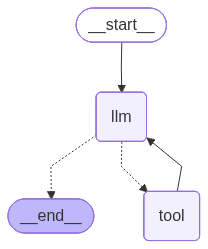

In [1]:
from typing import Literal
from langgraph.graph import StateGraph, END, MessagesState
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool



# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)


@tool
def get_leave_policy(query: str) -> str:
    """Returns company leave policy details."""

    query = query.lower()

    if "sick" in query:
        return "Employees get 5 sick leave days per year."
    elif "casual" in query:
        return "Employees get 20 casual leave days annually."
    elif "maternity" in query:
        return "Maternity leave is 26 weeks."
    elif "paternity" in query:
        return "Paternity leave is 5 days."

    return "Please check HR portal for more details."


tools = [get_leave_policy]

tools_by_name = {tool.name: tool for tool in tools}

model_with_tools = llm.bind_tools(tools)

# ---------------------------
# LLM Node
# ---------------------------
def call_llm(state: MessagesState):

    print("STATE MESSAGES:", state["messages"])

    response = model_with_tools.invoke(state["messages"])

    return {"messages": [response]}


# ---------------------------
# Tool Node
# ---------------------------
def call_tool(state: MessagesState):

    last_message = state["messages"][-1]

    tool_call = last_message.tool_calls[0]   # only one tool

    tool = tools_by_name[tool_call["name"]]

    tool_response = tool.invoke(tool_call["args"])

    return {
        "messages": [
            ToolMessage(
                content=tool_response,
                tool_call_id=tool_call["id"]
            )
        ]
    }


# ---------------------------
# Router
# ---------------------------
def should_continue(state: MessagesState) -> Literal["tool", END]:

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tool"

    return END


# ---------------------------
# Graph
# ---------------------------
builder = StateGraph(MessagesState)

builder.add_node("llm", call_llm)
builder.add_node("tool", call_tool)

builder.set_entry_point("llm")

builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tool": "tool",
        END: END
    }
)

builder.add_edge("tool", "llm")

graph = builder.compile()
builder.compile()



In [3]:
# ---------------------------
# Run
# ---------------------------
result = graph.invoke({
    "messages": [
        HumanMessage(content="How many maternity leave weeks do employees get?")
    ]
})

from rich import print
print("\nFINAL ANSWER:")
print(result["messages"][-1].content)

STATE MESSAGES: [HumanMessage(content='How many maternity leave weeks do employees get?', additional_kwargs={}, response_metadata={}, id='17a3a703-85f0-4da7-aec6-a5d1559be039')]
STATE MESSAGES: [HumanMessage(content='How many maternity leave weeks do employees get?', additional_kwargs={}, response_metadata={}, id='17a3a703-85f0-4da7-aec6-a5d1559be039'), AIMessage(content=[{'type': 'text', 'text': 'I will search for the maternity leave policy and relay the information to the user.'}, {'type': 'tool_use', 'name': 'get_leave_policy', 'input': {'query': 'maternity leave'}, 'id': 'tooluse_21yMaTA5IEft6FL6yN5yEc'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '2c59e9fb-6a1c-4b76-9a42-c36a9229fc97', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Tue, 10 Mar 2026 03:13:10 GMT', 'content-type': 'application/json', 'content-length': '407', 'connection': 'keep-alive', 'x-amzn-requestid': '2c59e9fb-6a1c-4b76-9a42-c36a9229fc97'}, 'RetryAttempts': 0}, 'stopReason': 't

FINAL ANSWER:

Employees get 26 weeks of maternity leave.

## With Tool Node

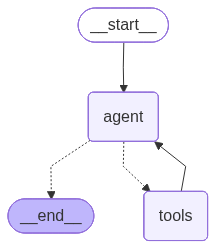

In [5]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool



# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)


# ---------------------------
# Tool
# ---------------------------
# ---------------------------
# Tool
# ---------------------------
@tool
def get_leave_policy(query: str) -> str:
    """Returns company leave policy details."""

    query = query.lower()

    if "sick" in query:
        return "Employees get 5 sick leave days per year."
    elif "casual" in query:
        return "Employees get 20 casual leave days annually."
    elif "maternity" in query:
        return "Maternity leave is 26 weeks."
    elif "paternity" in query:
        return "Paternity leave is 5 days."

    return "Please check HR portal for more details."

tools = [get_leave_policy]

llm_with_tools = llm.bind_tools(tools)

# ---------------------------
# Agent Node
# ---------------------------
def agent_node(state: MessagesState):

    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}


# ---------------------------
# Tool Node
# ---------------------------
tool_node = ToolNode(tools)


# ---------------------------
# Router (decide tool or end)
# ---------------------------
def should_continue(state: MessagesState):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END


# ---------------------------
# Build Graph
# ---------------------------
builder = StateGraph(MessagesState)

builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

builder.set_entry_point("agent")

builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

builder.add_edge("tools", "agent")

graph = builder.compile()
builder.compile()



In [6]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="How many sick leaves do employees get in total in a year?")
    ]
},)

print(result["messages"][-1].content)

Employees get 5 sick leave days per year.

In [7]:
from rich import print
print(result)

{
    'messages': [
        HumanMessage(
            content='How many sick leaves do employees get in total in a year?',
            additional_kwargs={},
            response_metadata={},
            id='27b63d89-32bf-4c02-b340-a37c5506c93f'
        ),
        AIMessage(
            content=[
                {'type': 'text', 'text': 'I will search for the number of sick leaves employees get in a year.'},
                {
                    'type': 'tool_use',
                    'name': 'get_leave_policy',
                    'input': {'query': 'sick leave'},
                    'id': 'tooluse_a9XbWXTHynrqiNwZ0EWT3i'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '874f34e5-26bf-45ed-af1c-75cf680484be',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Tue, 10 Mar 2026 03:13:43 GMT',
                        'content-type': 'application/json',
                        'content-length': '387',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '874f34e5-26bf-45ed-af1c-75cf680484be'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'tool_use',
                'metrics': {'latencyMs': [1925]},
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='run--db5050ce-b2a1-4b3f-b4aa-5a65fda07864-0',
            tool_calls=[
                {
                    'name': 'get_leave_policy',
                    'args': {'query': 'sick leave'},
                    'id': 'tooluse_a9XbWXTHynrqiNwZ0EWT3i',
                    'type': 'tool_call'
                }
            ],
            usage_metadata={
                'input_tokens': 25,
                'output_tokens': 27,
                'total_tokens': 52,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        ),
        ToolMessage(
            content='Employees get 5 sick leave days per year.',
            name='get_leave_policy',
            id='334c0c1c-cbbc-4fef-82c8-882194a3e90b',
            tool_call_id='tooluse_a9XbWXTHynrqiNwZ0EWT3i'
        ),
        AIMessage(
            content='Employees get 5 sick leave days per year.',
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '80a6a29e-2548-4c9f-aaa7-65b49940906b',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Tue, 10 Mar 2026 03:13:45 GMT',
                        'content-type': 'application/json',
                        'content-length': '244',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '80a6a29e-2548-4c9f-aaa7-65b49940906b'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'end_turn',
                'metrics': {'latencyMs': [1620]},
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='run--ad846300-3e43-4fc8-9d13-4e92a319b069-0',
            usage_metadata={
                'input_tokens': 62,
                'output_tokens': 10,
                'total_tokens': 72,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        )
    ]
}